In [ ]:
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid", color_codes=True)

In [2]:
df = pd.read_csv('/content/winequality-red.csv', delimiter=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
# Check for missing values
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
# Drop duplicates
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Number of Duplicated Values: {duplicate_count}")

Number of Duplicated Values: 240


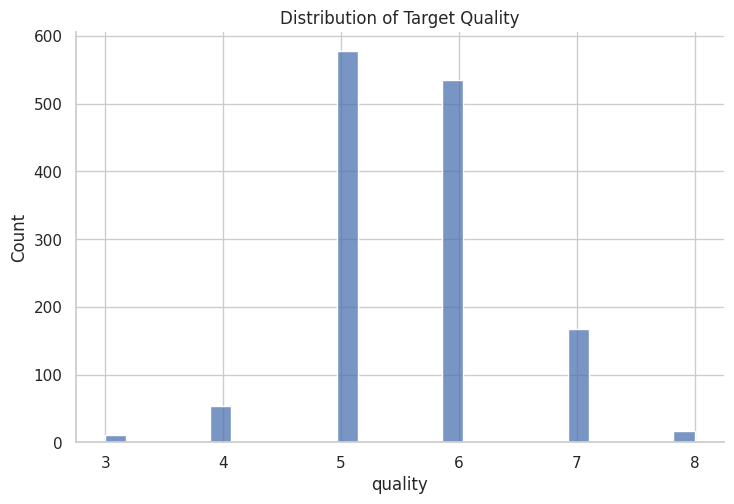

In [ ]:
# Target Distribution
sns.displot(df, x="quality", aspect=1.5)
plt.title("Distribution of Target Quality")
plt.show()

In [ ]:
# 0 if the quality is less than 5 else 1
df['quality'] = df['quality'].apply(lambda y_value: 1 if y_value > 5 else 0)

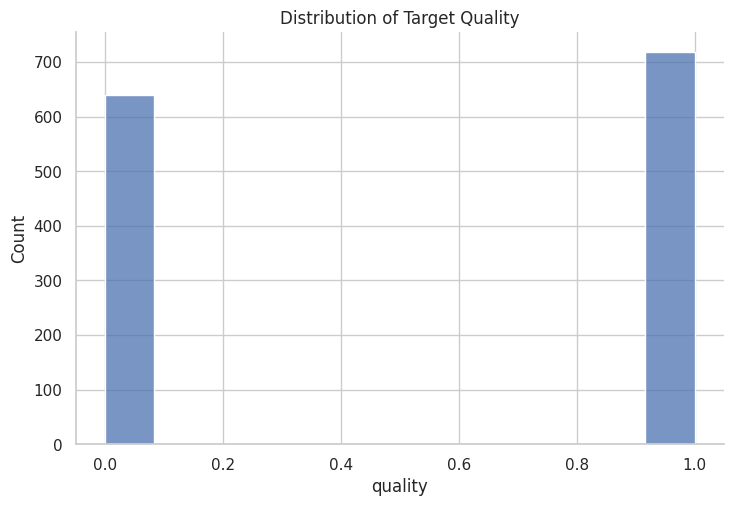

In [9]:
sns.displot(df, x="quality", aspect=1.5)
plt.title("Distribution of Target Quality")
plt.show()

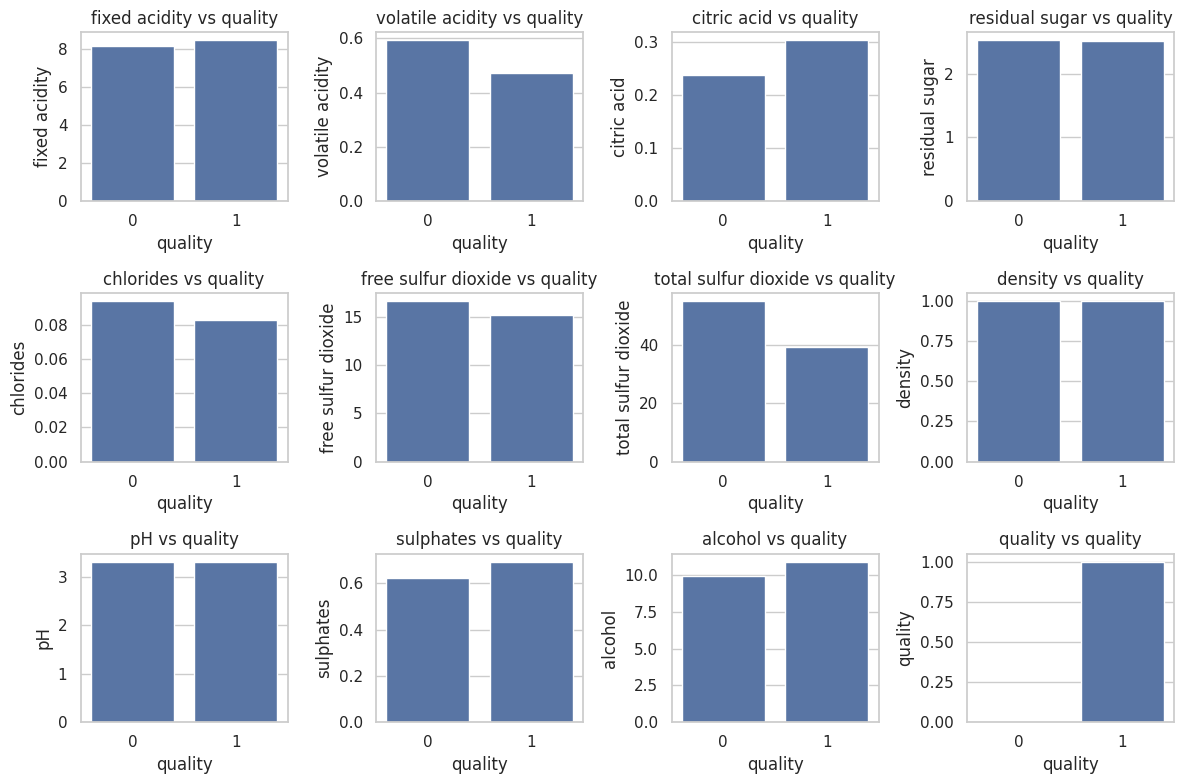

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.flatten()

for i, column in enumerate(df.columns.tolist()):
    sns.barplot(x="quality", y=column, data=df, ax=axes[i],  errorbar=None)
    axes[i].set_title(column + " vs quality", fontsize=12)
    axes[i].set_xlabel("quality", fontsize=12)
    axes[i].set_ylabel(column, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(df.drop('quality', axis=1),
                                                    df['quality'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((951, 11), (408, 11))

In [ ]:
# New Axis
y_train = y_train.values[:, np.newaxis]
y_test = y_test.values[:, np.newaxis]

In [ ]:
# Set up the scaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
class DecisionNode:
    """
    Class for a parent/leaf node in the decision tree.
    A Node with node information about it's left and right nodes if any. it has the impurity info also.
    """
    def __init__(self, impurity=None, question=None, feature_index=None, threshold=None,
                 true_subtree=None, false_subtree=None):

        self.impurity = impurity
        # Which question to ask , to split the dataset.
        self.question = question
        # Index of the feature which make the best fit for this node.
        self.feature_index = feature_index
        # The threshold value for that feature to make the split.
        self.threshold = threshold
        # DecisionNode Object of the left subtree.
        self.true_left_subtree = true_subtree
        # DecisionNode Object of the right subtree.
        self.false_right_subtree = false_subtree

class LeafNode:
    """ Leaf Node of the decision tree."""
    def __init__(self, value):
        self.prediction_value = value


class DecisionTree:
    """Common class for making decision tree for classification and regression tasks."""
    def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=float('inf'),
                 impurity_function=None, leaf_node_calculation=None):

        self.root = None

        self.min_sample_split = min_sample_split
        self.min_impurity = min_impurity
        self.max_depth = max_depth
        self.impurity_function = impurity_function
        self.leaf_node_calculation = leaf_node_calculation

    def _partition_dataset(self, Xy, feature_index, threshold):
        """
        Split the dataset based on the given feature and threshold.
        """
        split_func = None
        if isinstance(threshold, int) or isinstance(threshold, float):
            split_func = lambda sample: sample[feature_index] >= threshold
        else:
            split_func = lambda sample: sample[feature_index] == threshold

        X_1 = np.array([sample for sample in Xy if split_func(sample)])
        X_2 = np.array([sample for sample in Xy if not split_func(sample)])

        return X_1, X_2

    def _find_best_split(self, Xy):
        """
        Find the best question/best feature threshold which splits the data well.
        """
        best_question = tuple() # this will containe the feature and its value which make the best split(higest gain).
        best_datasplit = {} # best data split.
        largest_impurity = 0
        n_features = (Xy.shape[1] - 1)
        # iterate over all the features.
        for feature_index in range(n_features):
            # find the unique values in that feature.
            unique_value = set(s for s in Xy[:,feature_index])
            # iterate over all the unique values to find the impurity.
            for threshold in unique_value:
                # split the dataset based on the feature value.
                true_xy, false_xy = self._partition_dataset(Xy, feature_index, threshold)
                # skip the node which has any on type 0. because this means it is already pure.
                if len(true_xy) > 0 and len(false_xy) > 0:


                    # find the y values.
                    y = Xy[:, -1]
                    true_y = true_xy[:, -1]
                    false_y = false_xy[:, -1]

                    # calculate the impurity function.
                    impurity = self.impurity_function(y, true_y, false_y)

                    # if the calculated impurity is larger than save this value for comaparition.
                    if impurity > largest_impurity:
                        largest_impurity = impurity
                        best_question = (feature_index, threshold)
                        best_datasplit = {
                                    "leftX": true_xy[:, :n_features],   # X of left subtree
                                    "lefty": true_xy[:, n_features:],   # y of left subtree
                                    "rightX": false_xy[:, :n_features],  # X of right subtree
                                    "righty": false_xy[:, n_features:]   # y of right subtree
                        }

        return largest_impurity, best_question, best_datasplit

    def _build_tree(self, X, y, current_depth=0):
        """
        This is a recursive method to build the decision tree.
        """
        n_samples , n_features = X.shape
        # Add y as last column of X
        Xy = np.concatenate((X, y), axis=1)
        # find the Information gain on each feature each values and return the question which splits the data very well
        # based on the impurity function. (classfication - Information gain, regression - variance reduction).
        if (n_samples >= self.min_sample_split) and (current_depth <= self.max_depth):
            # find the best split/ which question split the data well.
            impurity, quesion, best_datasplit = self._find_best_split(Xy)
            if impurity > self.min_impurity:
            # Build subtrees for the right and left branch.
                true_branch = self._build_tree(best_datasplit["leftX"], best_datasplit["lefty"], current_depth + 1)
                false_branch = self._build_tree(best_datasplit["rightX"], best_datasplit["righty"], current_depth + 1)
                return DecisionNode( impurity=impurity, question=quesion, feature_index=quesion[0], threshold=quesion[1],
                                    true_subtree=true_branch, false_subtree=false_branch)

        leaf_value = self._leaf_value_calculation(y)
        return LeafNode(value=leaf_value)


    def train(self, X, y):
        """
        Build the decision tree.
        """
        self.root = self._build_tree(X, y, current_depth=0)

    def predict_sample(self, x, tree=None):
        """move form the top to bottom of the tree make a prediction of the sample by the
            value in the leaf node """
        if tree is None:
            tree = self.root
        # if it a leaf node the return the prediction.
        if isinstance(tree , LeafNode):

            return tree.prediction_value
        feature_value = x[tree.feature_index]

        branch = tree.false_right_subtree

        if isinstance(feature_value, int) or isinstance(feature_value, float):

            if feature_value >= tree.threshold:

                branch = tree.true_left_subtree
        elif feature_value == tree.threshold:
            branch = tree.true_left_subtree

        return self.predict_sample(x, branch)

    def predict(self, test_X):
        """ predict the unknow feature."""
        x = np.array(test_X)
        y_pred = [self.predict_sample(sample) for sample in x]
        # y_pred = np.array(y_pred)
        # y_pred = np.expand_dims(y_pred, axis = 1)
        return y_pred

    def draw_tree(self, tree = None, indentation = " "):
        """print the whole decitions of the tree from top to bottom."""
        if tree is None:
            tree = self.root

        def print_question(question, indention):
            feature_index = question[0]
            threshold = question[1]

            condition = "=="
            if isinstance(threshold, int) or isinstance(threshold, float):
                condition = ">="
            print(indention,"Is {col}{condition}{value}?".format(col=feature_index, condition=condition, value=threshold))

        if isinstance(tree , LeafNode):
            print(indentation,"The predicted value -->", tree.prediction_value)
            return

        else:
            # print the question.
            print_question(tree.question,indentation)
            if tree.true_left_subtree is not None:
                # travers to the true left branch.
                print (indentation + '----- True branch :)')
                self.draw_tree(tree.true_left_subtree, indentation + "  ")
            if tree.false_right_subtree is not None:
                # travers to the false right-side branch.
                print (indentation + '----- False branch :)')
                self.draw_tree(tree.false_right_subtree, indentation + "  ")



class DecisionTreeClassifier(DecisionTree):
    """ Decision Tree for the classification problem."""
    def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=float('inf'),
                 ):
        """
        min_sample_split: min value a leaf node must have.
        min_impurity: minimum impurity.
        max_depth: maximum depth of the tree.
        """
        self._impurity_function = self._claculate_information_gain
        self._leaf_value_calculation = self._calculate_majarity_class
        super(DecisionTreeClassifier, self).__init__(min_sample_split=min_sample_split, min_impurity=min_impurity, max_depth=max_depth,
                         impurity_function=self._impurity_function, leaf_node_calculation=self._leaf_value_calculation)

    def _entropy(self, y):
        """ Find the entropy for the given data"""
        entropy = 0
        unique_value = np.unique(y)
        for val in unique_value:
            # probability of that class.
            p = len(y[y==val]) / len(y)
            entropy += -p * (math.log(p) / math.log(2))
        return entropy


    def _claculate_information_gain(self, y, y1, y2):
        """
        Calculate the information gain.
        """
        # propobility of true values.
        p = len(y1) / len(y)
        entropy = self._entropy(y)
        info_gain = entropy - p * self._entropy(y1) - (1 - p) * self._entropy(y2)
        return info_gain

    def _calculate_majarity_class(self, y):
        """
        calculate the prediction value for that leaf node.
        """
        most_frequent_label = None
        max_count = 0
        unique_labels = np.unique(y)
        # iterate over all the unique values and find their frequentcy count.
        for label in unique_labels:
            count = len( y[y == label])
            if count > max_count:
                most_frequent_label = label
                max_count = count
        return most_frequent_label

    def train(self, X, y):
        """
        Build the tree
        """
        # train the model.
        super(DecisionTreeClassifier, self).train(X, y)

    def predict(self, test_X):
        """ predict the unknow feature."""
        y_pred = super(DecisionTreeClassifier, self).predict(test_X)
        y_pred = np.array(y_pred)
        y_pred = np.expand_dims(y_pred, axis = 1)
        return y_pred


In [16]:
class RandomForest:
    """    Random forest common class.    """
    def __init__(self, trees, n_trees, max_feature ,
                 prediction_aggrigation_calculation):
        """
        trees: List - list of tree objects. classification tree/regression trees.
        n_trees: int - How may estimators/tree should be used for random forest building.
        max_feature: Int - How many features can be used for a tree from the whole features.
        prediction_aggrigation_calculation: Function - Aggication function to find the prediction.
        """
        self.n_estimators = n_trees
        self.max_features = max_feature
        self.tree_feature_indexes = []
        self.prediction_aggrigation_calculation = prediction_aggrigation_calculation
        # Initialize the trees.
        self.trees = trees

    def _make_random_suset(self, X, y, n_subsets, replasment=True):
        """
        Creata a random subset of dataset with/without replacement.
        """
        subset = []
        # use 100% of data when replacement is true , use 50% otherwise.
        sample_size = (X.shape[0] if replasment else (X.shape[0] // 2))

        # First concadinate the X and y datasets in order to make a choice.
        Xy = np.concatenate((X, y), axis=1)
        np.random.shuffle(Xy)
        # Select randome subset of data with replacement.
        for i in range(n_subsets):
            index = np.random.choice(range(sample_size), size=np.shape(range(sample_size)), replace=replasment)
            X = Xy[index][:, :-1]
            y = Xy[index][: , -1]
            subset.append({"X" : X, "y": y})
        return subset

    def train(self, X, y):
        """
        Build the model.
        """
        # if the max_features is not given then select it as square root of no on feature availabe.
        n_features = X.shape[1]
        if self.max_features == None:
            self.max_features = int(math.sqrt(n_features))

        # Split the dataset into number of subsets equal to n_estimators.
        subsets = self._make_random_suset(X, y, self.n_estimators)

        for i, subset in enumerate(subsets):
            X_subset , y_subset = subset["X"], subset["y"]
            # select a random sucset of features for each tree. This is called feature bagging.
            idx = np.random.choice(range(n_features), size=self.max_features, replace=True)
            # track this for prediction.
            self.tree_feature_indexes.append(idx)
            # Get the X with the selected features only.
            X_subset = X_subset[:, idx]

            # change the y_subet to i dimentional array.
            y_subset = np.expand_dims(y_subset, axis =1)
            # build the model with selected features and selected random subset from dataset.
            self.trees[i].train(X_subset, y_subset)

    def predict(self, test_X):
        """
        Predict the new samples.
        """
        # predict each sample one by one.
        y_preds = np.empty((test_X.shape[0], self.n_estimators))
        # find the prediction from each tree for eeach samples
        for i, tree in enumerate(self.trees):
            features_index = self.tree_feature_indexes[i]
            X_selected_features = test_X[:, features_index]
            if isinstance(tree, DecisionTreeClassifier):
                y_preds[:, i] = tree.predict(X_selected_features).reshape((-1,))
            else:
                y_preds[:, i] = tree.predict(X_selected_features)
        # find the arrgrecated output.
        y_pred = self.prediction_aggrigation_calculation(y_preds)

        return y_pred


class RandomForestClassifier(RandomForest):
    """Rnadom forest for classification task."""
    def __init__(self, max_feature, max_depth, n_trees=100, min_sample_split=2, min_impurity=1e-7):
        """
        max_depth: Int - Max depth of each tree.
        n_trees: Int - Number of trees/estimetors.
        min_sample_split: Int - minimum samples for a node to have before going for split.
        min_impurity: Int - Min inpurity a node can have.
        """
        self.prediction_aggrigation_calculation = self._maximum_vote_calculation

        # Initializing the trees.
        self.trees = []
        for _ in range(n_trees):
            self.trees.append(DecisionTreeClassifier(min_sample_split=min_sample_split,
                                                     min_impurity=min_impurity, max_depth=max_depth))

        super().__init__(trees=self.trees, n_trees=n_trees,max_feature=max_feature,
                         prediction_aggrigation_calculation=self.prediction_aggrigation_calculation)

    def _maximum_vote_calculation(self, y_preds):
        """
        Find which prediction class has higest frequency in all tree prediction for each sampple.
        """
        # create a empty array to store the prediction.
        y_pred = np.empty((y_preds.shape[0], 1))
        # iterate over all the data samples.
        for i, sample_predictions in enumerate(y_preds):
            y_pred[i] = np.bincount(sample_predictions.astype('int')).argmax()

        return y_pred

In [ ]:
param_grid = {
    'max_depth': [2, 6, 8, 10],
    'min_sample_split': [2, 5, 10],
    'n_trees': [20, 40, 60, 80    ]
}

results = {}

# Iterate through all parameter combinations
for max_depth in tqdm(param_grid['max_depth']):
    for min_sample_split in param_grid['min_sample_split']:
        for n_estimators in param_grid['n_trees']:

            rf = RandomForestClassifier(
                max_depth=max_depth,
                max_feature=None,
                min_sample_split=min_sample_split,
                n_trees=n_estimators,
            )

            rf.train(X_train, y_train)

            y_pred = rf.predict(X_test)
            acc = np.sum(y_test==y_pred)/X_test.shape[0]

            key = f"max_depth={max_depth}, max_feature=None, min_sample_split={min_sample_split}, n_trees={n_estimators}"
            results[key] = acc

100%|██████████| 4/4 [1:00:10<00:00, 902.75s/it]


In [34]:
# Find the best combination
best_combination = max(results, key=results.get)
print(f"Best combination: {best_combination}")
print("*"*40)
print(f"Best score: {results[best_combination]}")

Best combination: max_depth=10, max_feature=None, min_sample_split=2, n_trees=80
****************************************
Best score: 0.7622549019607843


In [35]:
# Print all results
for params, score in results.items():
    print(f"{params}: {score}")
    print("-"*40)

max_depth=2, max_feature=None, min_sample_split=2, n_trees=20: 0.7377450980392157
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=2, n_trees=40: 0.7083333333333334
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=2, n_trees=60: 0.7279411764705882
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=2, n_trees=80: 0.7230392156862745
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=5, n_trees=20: 0.696078431372549
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=5, n_trees=40: 0.7303921568627451
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=5, n_trees=60: 0.75
----------------------------------------
max_depth=2, max_feature=None, min_sample_split=5, n_trees=80: 0.7377450980392157
----------------------------------------
max_depth=2, max_feature=None, 

In [41]:
# Convert the best parameter to key value pair
pairs = dict(item.split('=') for item in best_combination.split(', '))

for key, value in pairs.items():
    if value.isdigit():
        pairs[key] = int(value)
    elif value == "None":
        pairs[key] = None

In [ ]:
# Train and Preidct RF with the best parameters
rf = RandomForestClassifier(**pairs)

rf.train(X_train, y_train)


y_pred = rf.predict(X_test)
acc = np.sum(y_test==y_pred)/X_test.shape[0]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.79      0.74       192
           1       0.79      0.68      0.73       216

    accuracy                           0.73       408
   macro avg       0.74      0.74      0.73       408
weighted avg       0.74      0.73      0.73       408



In [47]:
confusion_matrix(y_test, y_pred)

array([[152,  40],
       [ 69, 147]])